# Glance Fashion Retrieval — Exploration & Ablation Notebook

This notebook covers:
1. **Dataset EDA** — distribution of environment, style, dominant color
2. **2D Projection** — PCA/UMAP of CLIP embeddings colored by environment
3. **Ablation** — CLIP-only vs Text-only vs Hybrid on the 5 eval queries
4. **Weight Sensitivity** — vary α on the compositional query (query 5)
5. **Query Parser Verification** — structured parse of all 5 eval queries

> **Run the indexer first**: `python -m Part_A_Indexer.run_indexer --mode full`

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from collections import Counter
from dotenv import load_dotenv

# Add repo root to path so imports work from the notebooks/ directory
REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))
load_dotenv(REPO_ROOT / '.env')

plt.rcParams.update({
    'figure.facecolor': '#0f0f13',
    'axes.facecolor': '#1a1a24',
    'axes.edgecolor': '#2a2a3a',
    'text.color': '#e8e8f0',
    'axes.labelcolor': '#e8e8f0',
    'xtick.color': '#888899',
    'ytick.color': '#888899',
    'grid.color': '#2a2a3a',
    'figure.dpi': 120,
})

CAPTIONS_FILE = REPO_ROOT / 'data' / 'captions.json'
print(f'Repo root: {REPO_ROOT}')
print(f'Captions file exists: {CAPTIONS_FILE.exists()}')

Repo root: C:\Glance\glance-fashion-retrieval
Captions file exists: True


## 1. Dataset EDA

In [2]:
# Load captions
with open(CAPTIONS_FILE) as f:
    captions = json.load(f)

df = pd.DataFrame([
    {
        'image_id': img_id,
        'environment': cap.get('environment', 'unknown'),
        'style': cap.get('style', 'unknown'),
        'dominant_color': cap.get('dominant_color', 'unknown'),
        'n_clothing_items': len(cap.get('clothing_items', [])),
        'n_colors': len(cap.get('colors', [])),
        'parse_tier': cap.get('parse_tier_used', -1),
    }
    for img_id, cap in captions.items()
])

print(f'Total images with captions: {len(df)}')
print(df.describe())

Total images with captions: 1000
       n_clothing_items     n_colors  parse_tier
count       1000.000000  1000.000000      1000.0
mean           0.787000     0.605000         3.0
std            0.874297     0.815868         0.0
min            0.000000     0.000000         3.0
25%            0.000000     0.000000         3.0
50%            1.000000     0.000000         3.0
75%            2.000000     1.000000         3.0
max            4.000000     4.000000         3.0


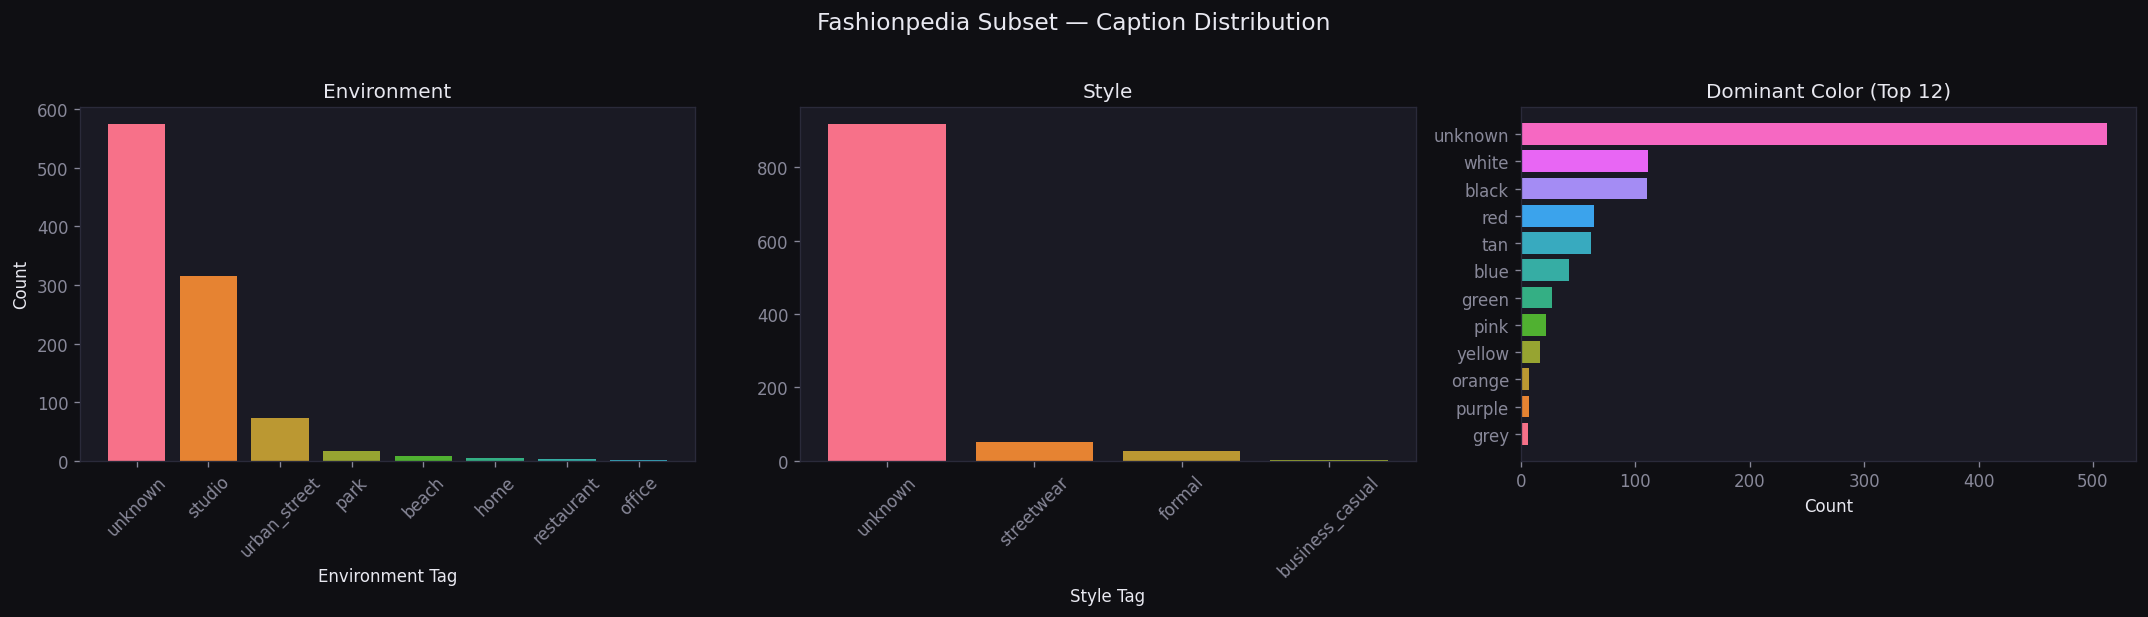

Parse tier distribution (1=VLM JSON, 2=regex, 3=heuristic):
parse_tier
3    1000
Name: count, dtype: int64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fashionpedia Subset — Caption Distribution', fontsize=14, y=1.02)

palette = sns.color_palette('husl', 12)

# Environment distribution
env_counts = df['environment'].value_counts()
axes[0].bar(env_counts.index, env_counts.values, color=palette[:len(env_counts)])
axes[0].set_title('Environment')
axes[0].set_xlabel('Environment Tag')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Style distribution
style_counts = df['style'].value_counts()
axes[1].bar(style_counts.index, style_counts.values, color=palette[:len(style_counts)])
axes[1].set_title('Style')
axes[1].set_xlabel('Style Tag')
axes[1].tick_params(axis='x', rotation=45)

# Top 12 dominant colors
color_counts = df['dominant_color'].value_counts().head(12)
axes[2].barh(color_counts.index[::-1], color_counts.values[::-1], color=palette)
axes[2].set_title('Dominant Color (Top 12)')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks' / 'eda_distribution.png', bbox_inches='tight', facecolor='#0f0f13')
plt.show()
print(f'Parse tier distribution (1=VLM JSON, 2=regex, 3=heuristic):')
print(df['parse_tier'].value_counts())

## 2. 2D Projection of CLIP Embeddings

If the CLIP embedding space has learned meaningful visual structure, images with similar environments should cluster together in 2D. This validates our assumption that the CLIP collection provides useful setting/aesthetic signal.

In [4]:
from Part_A_Indexer.vector_store import FashionVectorStore

CHROMA_DIR = REPO_ROOT / 'chroma_db'
vs = FashionVectorStore(persist_dir=CHROMA_DIR)

# Fetch all embeddings from the CLIP collection
# ChromaDB's .get() returns everything when no IDs are specified
clip_collection = vs._clip_collection
all_data = clip_collection.get(include=['embeddings', 'metadatas'])

embeddings = np.array(all_data['embeddings'])
metadatas = all_data['metadatas']
environments = [m.get('environment', 'unknown') for m in metadatas]

print(f'Fetched {len(embeddings)} CLIP embeddings, shape={embeddings.shape}')

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


Fetched 1000 CLIP embeddings, shape=(1000, 512)


PCA explained variance: 21.1%
2D projection via PCA: (1000, 2)


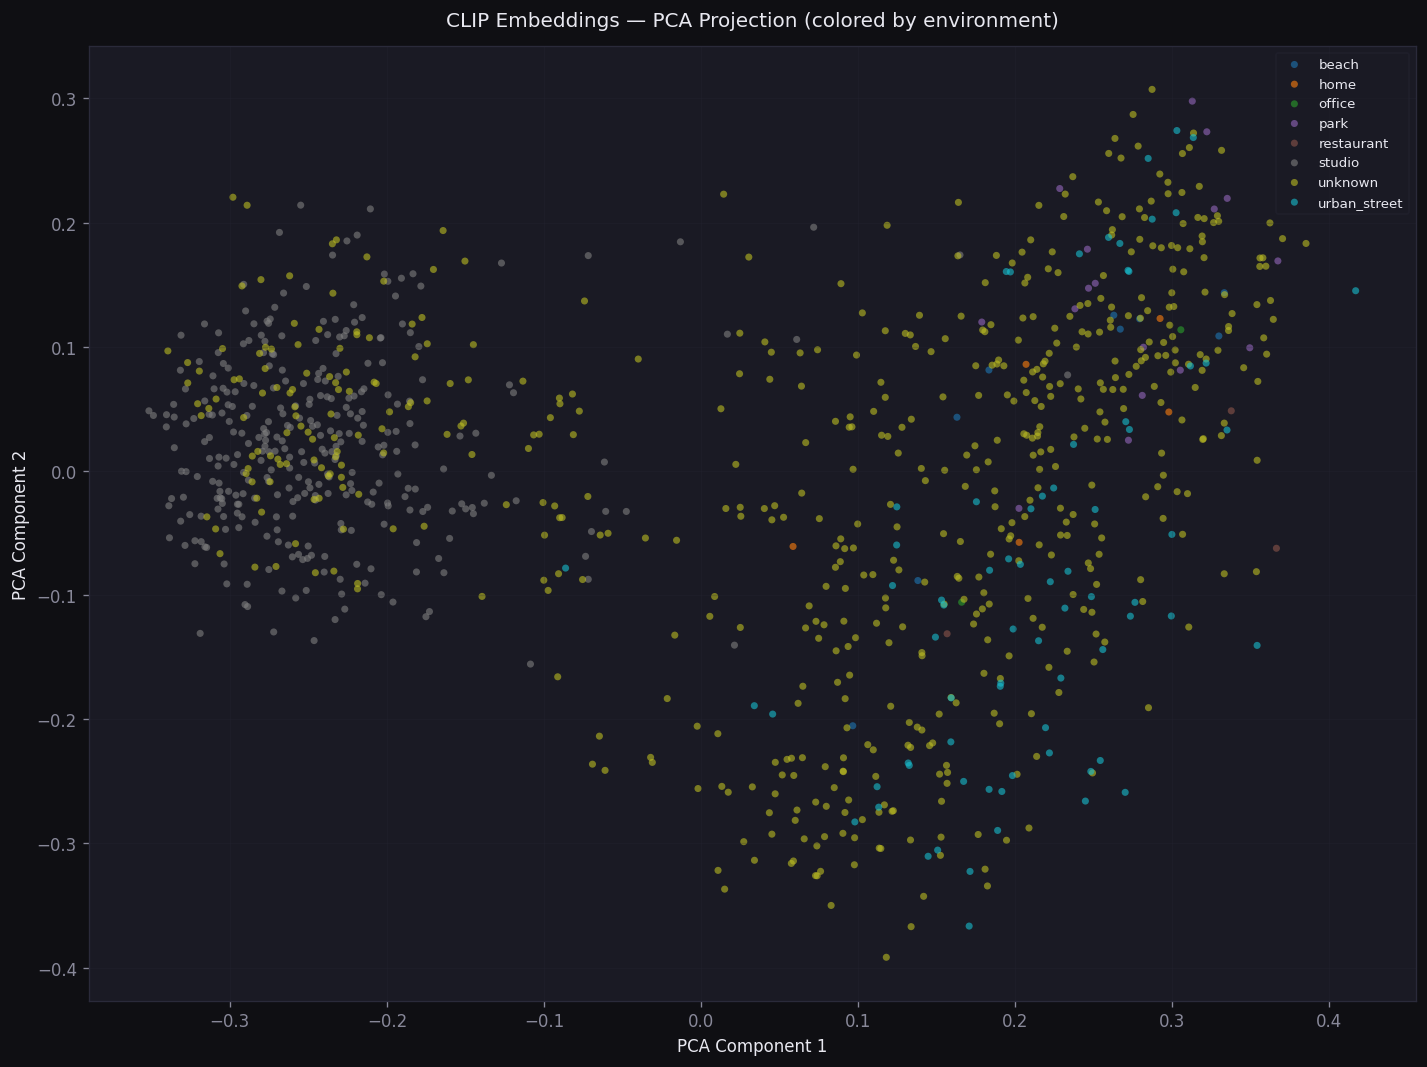

In [5]:
from sklearn.decomposition import PCA

# Try UMAP first (better structure preservation), fall back to PCA
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    coords_2d = reducer.fit_transform(embeddings)
    method = 'UMAP'
except ImportError:
    pca = PCA(n_components=2, random_state=42)
    coords_2d = pca.fit_transform(embeddings)
    method = 'PCA'
    print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

print(f'2D projection via {method}: {coords_2d.shape}')

# Plot
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#0f0f13')
ax.set_facecolor('#1a1a24')

unique_envs = sorted(set(environments))
colors = cm.tab10(np.linspace(0, 1, len(unique_envs)))
env_to_color = dict(zip(unique_envs, colors))

for env in unique_envs:
    mask = [e == env for e in environments]
    pts = coords_2d[mask]
    ax.scatter(pts[:, 0], pts[:, 1], c=[env_to_color[env]], label=env, alpha=0.6, s=18, edgecolors='none')

ax.legend(loc='upper right', fontsize=8, framealpha=0.3, facecolor='#1a1a24', edgecolor='#2a2a3a')
ax.set_title(f'CLIP Embeddings — {method} Projection (colored by environment)', pad=12)
ax.set_xlabel(f'{method} Component 1')
ax.set_ylabel(f'{method} Component 2')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks' / 'clip_2d_projection.png', bbox_inches='tight', facecolor='#0f0f13')
plt.show()

## 3. Ablation: CLIP-only vs Text-only vs Hybrid

We run the 5 official queries under 3 configurations to show the hybrid system's advantage — especially on the compositional query (query 5).

In [6]:
from Part_A_Indexer.feature_extractor import DualEmbedder
from Part_B_Retriever.query_parser import QueryParser
from Part_B_Retriever.retriever import HybridRetriever
from Part_B_Retriever.run_retrieval import EVAL_QUERIES

embedder = DualEmbedder()
query_parser = QueryParser()

configs = [
    {'name': 'CLIP-only',  'alpha': 1.0, 'beta': 0.0, 'gamma': 0.0},
    {'name': 'Text-only',  'alpha': 0.0, 'beta': 1.0, 'gamma': 0.0},
    {'name': 'Hybrid',     'alpha': 0.35, 'beta': 0.50, 'gamma': 0.15},
]

ablation_results = {}
for cfg in configs:
    retriever = HybridRetriever(
        vector_store=vs,
        embedder=embedder,
        query_parser=query_parser,
        alpha=cfg['alpha'],
        beta=cfg['beta'],
        gamma=cfg['gamma'],
    )
    ablation_results[cfg['name']] = {}
    for query in EVAL_QUERIES:
        results, _ = retriever.retrieve(query, top_k=3)
        ablation_results[cfg['name']][query] = results

print('Ablation results computed.')

01:13:40 [INFO] Part_A_Indexer.feature_extractor: [DualEmbedder] Initialized (device=cpu, CLIP=ViT-B-32/openai, text=BAAI/bge-small-en-v1.5). Models load lazily on first use.


01:13:41 [INFO] Part_B_Retriever.query_parser: [QueryParser] Groq LLM parser initialized.


01:13:41 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


01:13:41 [INFO] Part_B_Retriever.retriever: [HybridRetriever] Query parsed via llm: items=['raincoat'], env=unknown, style=casual


C:\Users\Aayush\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


...

01:14:45 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


01:14:45 [INFO] Part_B_Retriever.retriever: [HybridRetriever] Query parsed via llm: items=['tie', 'shirt'], env=office, style=formal


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 38.26it/s]

Ablation results computed.


In [7]:
print('=== Ablation Results: Top-3 per Config per Query ===\n')
for q_idx, query in enumerate(EVAL_QUERIES):
    print(f'Query {q_idx+1}: {query}')
    print('-' * 70)
    for cfg_name in ['CLIP-only', 'Text-only', 'Hybrid']:
        results = ablation_results[cfg_name][query]
        print(f'  [{cfg_name}]')
        for rank, r in enumerate(results, 1):
            meta = r.metadata
            print(
                f'    #{rank}: {r.image_id:<20}  score={r.fused_score:.4f}  '
                f'[{meta.get("style","?")[:10]:10s} | {meta.get("environment","?")[:12]:12s}]'
            )
    print()

=== Ablation Results: Top-3 per Config per Query ===

Query 1: A person in a bright yellow raincoat.
----------------------------------------------------------------------
  [CLIP-only]
    #1: 2c72aa2fceaf703ccb2f8573d09a1d94  score=0.2691  [unknown    | unknown     ]
    #2: daa5986d4a683b547328db6dce8d7817  score=0.2677  [streetwear | urban_street]
    #3: 063053841bae486b4c35f00d361e0b2e  score=0.2553  [unknown    | unknown     ]
  [Text-only]
    #1: d5420eb0d6e13003799778f0157b0a0e  score=0.7503  [unknown    | unknown     ]
    #2: bb48a572b525975f60627fdea9cfaf0a  score=0.7392  [unknown    | unknown     ]
    #3: 9c0aee7bd2e5b9c8fb1893a689f1f6be  score=0.7268  [business_c | unknown     ]
  [Hybrid]
    #1: e91677348e11b75ee3ccdb9c8fd78032  score=0.4291  [unknown    | unknown     ]
    #2: d5420eb0d6e13003799778f0157b0a0e  score=0.3751  [unknown    | unknown     ]
    #3: bb48a572b525975f60627fdea9cfaf0a  score=0.3696  [unknown    | unknown     ]

Query 2: Professional business a

## 4. Fusion Weight Sensitivity Sweep

Vary α (CLIP weight) from 0 → 1 (β = 1-α, γ=0) on the **compositional query** (Query 5: *"A red tie and a white shirt in a formal setting"*) to show how the top-1 result changes.

In [8]:
COMPOSITIONAL_QUERY = EVAL_QUERIES[4]  # "A red tie and a white shirt in a formal setting."
alpha_values = np.linspace(0, 1, 11)

sweep_results = []
for alpha in alpha_values:
    beta = 1.0 - alpha
    r = HybridRetriever(
        vector_store=vs,
        embedder=embedder,
        query_parser=query_parser,
        alpha=alpha, beta=beta, gamma=0.0,
    )
    results, _ = r.retrieve(COMPOSITIONAL_QUERY, top_k=1)
    top1 = results[0] if results else None
    sweep_results.append({
        'alpha': round(float(alpha), 2),
        'beta': round(float(beta), 2),
        'top1_id': top1.image_id if top1 else 'N/A',
        'top1_score': round(top1.fused_score, 4) if top1 else 0.0,
        'top1_clip': round(top1.clip_score, 4) if top1 else 0.0,
        'top1_text': round(top1.text_score, 4) if top1 else 0.0,
    })

sweep_df = pd.DataFrame(sweep_results)
print(f'Query: {COMPOSITIONAL_QUERY}')
print(sweep_df.to_string(index=False))

01:14:45 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


01:14:45 [INFO] groq._base_client: Retrying request to /openai/v1/chat/completions in 5.000000 seconds


01:14:50 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


01:14:50 [INFO] Part_B_Retriever.retriever: [HybridRetriever] Query parsed via llm: items=['tie', 'shirt'], env=office, style=formal


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

01:15:43 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


01:15:43 [INFO] Part_B_Retriever.retriever: [HybridRetriever] Query parsed via llm: items=['tie', 'shirt'], env=office, style=formal


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 41.69it/s]

Query: A red tie and a white shirt in a formal setting.
 alpha  beta                          top1_id  top1_score  top1_clip  top1_text
   0.0   1.0 13ac5b09f6c7cf03d6bddeeba2dd7d63      0.6920     0.2752      0.692
   0.1   0.9 13ac5b09f6c7cf03d6bddeeba2dd7d63      0.6503     0.2752      0.692
   0.2   0.8 13ac5b09f6c7cf03d6bddeeba2dd7d63      0.6086     0.2752      0.692
   0.3   0.7 13ac5b09f6c7cf03d6bddeeba2dd7d63      0.5669     0.2752      0.692
   0.4   0.6 13ac5b09f6c7cf03d6bddeeba2dd7d63      0.5253     0.2752      0.692
   0.5   0.5 13ac5b09f6c7cf03d6bddeeba2dd7d63      0.4836     0.2752      0.692
   0.6   0.4 13ac5b09f6c7cf03d6bddeeba2dd7d63      0.4419     0.2752      0.692
   0.7   0.3 13ac5b09f6c7cf03d6bddeeba2dd7d63      0.4002     0.2752      0.692
   0.8   0.2 13ac5b09f6c7cf03d6bddeeba2dd7d63      0.3586     0.2752      0.692
   0.9   0.1 13ac5b09f6c7cf03d6bddeeba2dd7d63      0.3169     0.2752      0.692
   1.0   0.0 13ac5b09f6c7cf03d6bddeeba2dd7d63      0.2752     0.

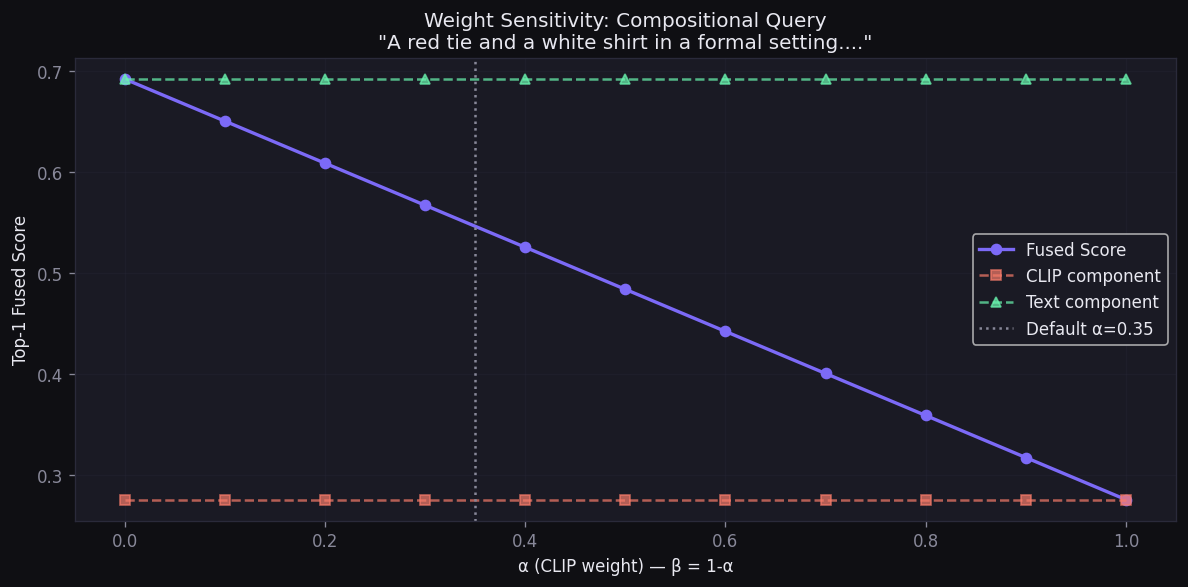

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep_df['alpha'], sweep_df['top1_score'], 'o-', color='#7c6af7', linewidth=2, label='Fused Score')
ax.plot(sweep_df['alpha'], sweep_df['top1_clip'], 's--', color='#f77c6a', linewidth=1.5, alpha=0.7, label='CLIP component')
ax.plot(sweep_df['alpha'], sweep_df['top1_text'], '^--', color='#6af7b0', linewidth=1.5, alpha=0.7, label='Text component')
ax.axvline(x=0.35, color='#888899', linestyle=':', linewidth=1.5, label='Default α=0.35')
ax.set_xlabel('α (CLIP weight) — β = 1-α')
ax.set_ylabel('Top-1 Fused Score')
ax.set_title(f'Weight Sensitivity: Compositional Query\n"{COMPOSITIONAL_QUERY[:60]}..."')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks' / 'weight_sweep.png', bbox_inches='tight', facecolor='#0f0f13')
plt.show()

## 5. Query Parser Verification

Demonstrate that the parsing step correctly decomposes each query into structured form — this is the foundation of the attribute-match bonus and filter mechanism.

In [10]:
from Part_B_Retriever.query_parser import QueryParser

parser = QueryParser()  # Will use LLM if GROQ_API_KEY is set, else rule-based

print('=== Query Parser Verification — All 5 Eval Queries ===\n')
for i, query in enumerate(EVAL_QUERIES, 1):
    parsed = parser.parse(query)
    print(f'Query {i}: {query}')
    print(f'  Parse method:  {parsed.parse_method}')
    print(f'  Clothing items: {parsed.clothing_items}')
    print(f'  Colors (bound): {parsed.colors}')
    print(f'  Environment:   {parsed.environment} (filter={parsed.filter_environment})')
    print(f'  Style:         {parsed.style} (filter={parsed.filter_style})')
    print(f'  Expanded query (first 120 chars):')
    print(f'    {parsed.expanded_query[:120]}')
    print()

print('Key observations:')
print('  - Query 5 (compositional) should produce TWO color-garment pairs: ["red tie", "white shirt"]')
print('  - Query 2 (contextual) should set environment=office and style=business_casual')
print('  - Query 4 (style inference) should infer casual style from context without explicit clothing listed')

01:15:43 [INFO] Part_B_Retriever.query_parser: [QueryParser] Groq LLM parser initialized.


01:15:43 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


01:15:43 [INFO] groq._base_client: Retrying request to /openai/v1/chat/completions in 4.000000 seconds


=== Query Parser Verification — All 5 Eval Queries ===



01:15:48 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


...

01:16:03 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


01:16:03 [INFO] groq._base_client: Retrying request to /openai/v1/chat/completions in 5.000000 seconds


Query 4: Casual weekend outfit for a city walk.
  Parse method:  llm
  Clothing items: ['jeans', 'sneakers', 't-shirt', 'jacket']
  Colors (bound): []
  Environment:   urban_street (filter=False)
  Style:         casual (filter=False)
  Expanded query (first 120 chars):
    A person in casual everyday clothing like jeans, sneakers, and a relaxed top or jacket, walking through an urban city en



01:16:09 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Query 5: A red tie and a white shirt in a formal setting.
  Parse method:  llm
  Clothing items: ['tie', 'shirt']
  Colors (bound): ['red tie', 'white shirt']
  Environment:   office (filter=False)
  Style:         formal (filter=True)
  Expanded query (first 120 chars):
    A man wearing a red necktie paired with a white dress shirt in a formal business or black-tie setting.

Key observations:
  - Query 5 (compositional) should produce TWO color-garment pairs: ["red tie", "white shirt"]
  - Query 2 (contextual) should set environment=office and style=business_casual
  - Query 4 (style inference) should infer casual style from context without explicit clothing listed
